# 18 — Análisis de una liga (Ligue 1): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "Ligue 1"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

Ligue 1: 8,811 jugador-temporadas, 3,200 jugadores, 37 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,20,38.0,543,0.989,0.997
2011-2012,20,38.0,549,0.992,0.996
2012-2013,20,38.0,562,0.991,0.996
2013-2014,20,38.0,560,0.991,0.997
2014-2015,20,38.0,545,0.993,0.997
2015-2016,20,38.0,588,0.993,0.997
2016-2017,20,38.0,575,0.991,0.998
2017-2018,20,38.0,553,0.993,0.997
2018-2019,20,38.0,561,0.994,0.996


8,811 jugador-temporadas de 3,200 jugadores en 37 clubes. La liga cambió de tamaño en el periodo: 20 equipos y 38
partidos hasta 2022-23, y 18 equipos con 34 partidos desde 2023-24; además 2019-20 se cortó por COVID (28 partidos).
Cobertura de minutos del 98.9% al 99.8%.

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

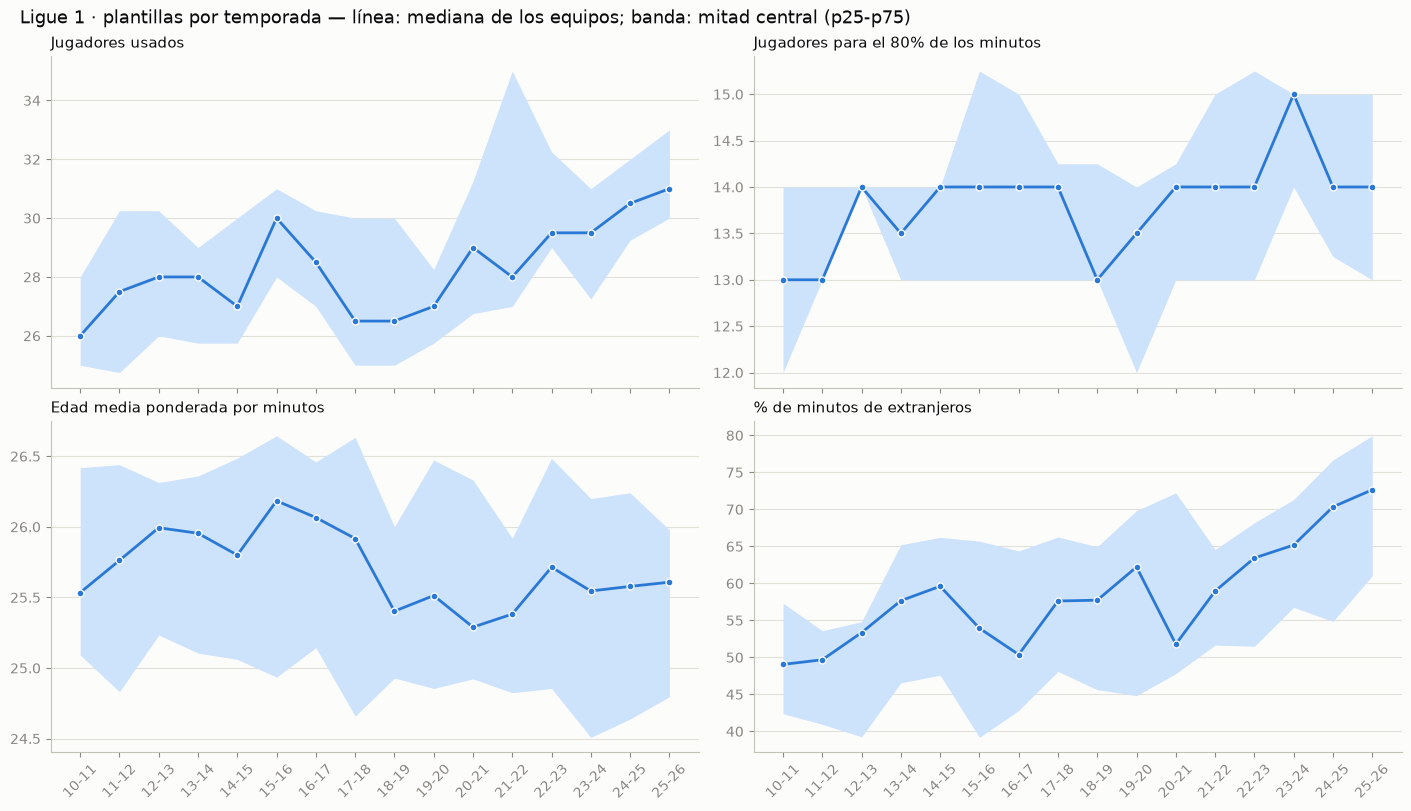

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

- **La mayor subida de extranjeros de las siete ligas**: del 49% de los minutos en 2010-11 al **72.6%** en 2025-26.
- **Rotación creciente**: los jugadores usados pasaron de 26-28 a 29.5-31, aunque los necesarios para el 80% de los
  minutos se mantienen en 13-15.
- **Liga joven y con muchos minutos para juveniles**: edad de quien juega entre 25.3 y 26.2 años, y entre 11.6% y
  20.9% de los minutos para jugadores de 21 años o menos.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
100,2015-2016,Bordeaux,35,18,24.4,61.2,1.3
104,2015-2016,Troyes,33,18,26.0,39.2,0.5
179,2018-2019,Monaco,42,18,25.2,85.8,0.9
215,2020-2021,PSG,33,18,26.1,78.6,2.2
220,2021-2022,Bordeaux,39,18,25.2,59.2,0.8
236,2021-2022,Metz,36,18,25.4,63.2,0.8


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
10,2010-2011,Lille,22,11,25.3,42.4,2.0
23,2011-2012,Montpellier,23,11,25.7,54.2,2.2
72,2013-2014,Lille,22,11,26.4,58.0,1.9
84,2014-2015,Marseille,25,11,25.2,49.4,1.8
164,2018-2019,Montpellier,25,11,27.5,46.0,1.6
184,2019-2020,Montpellier,27,11,28.0,45.3,1.4


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.35


Rotar se asocia con perder (**−0.35**), con una excepción llamativa: el **PSG 2020-21** repartió el 80% de sus
minutos entre 18 jugadores y aun así sumó 2.2 puntos por partido — cuando la plantilla es mucho mejor que la liga,
rotar no cuesta. Los demás equipos que más rotaron (Bordeaux 2015-16 y 2021-22, Troyes, Metz) quedaron entre 0.5 y
1.3. Los que menos rotaron fueron campeones: **Lille 2010-11** (11 jugadores, 2.0) y **Montpellier 2011-12** (11,
2.2).

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

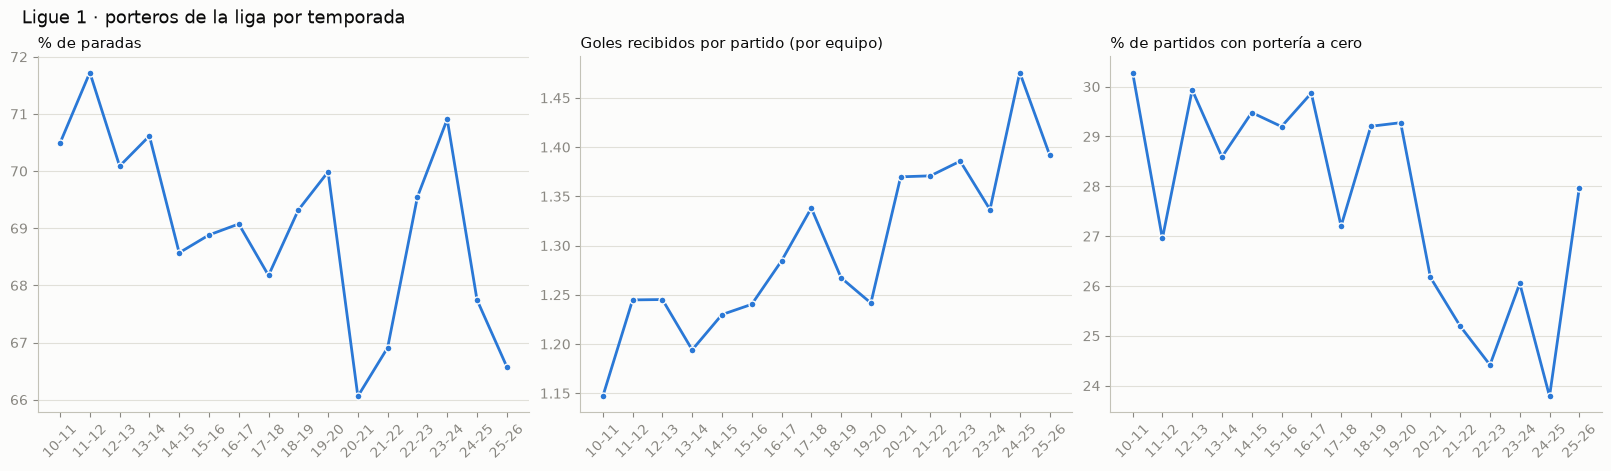

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **% de paradas**: de 70.5% (2010-11) a 66.6% (2025-26), con un repunte en 2023-24 (70.9%).
- **Goles recibidos por partido**: la liga arrancó como la menos goleada del panel (1.15 en 2010-11) y hoy está en
  1.39-1.48, sus valores más altos.
- **Porterías a cero**: de 30.3% al inicio a 23.8-28% en las últimas temporadas.

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
10dc46f0,Salvatore Sirigu,PSG,2011,2015,145.0,77.55,44.83,0.75
08f5afaa,Gianluigi Donnarumma,PSG,2021,2024,104.0,75.49,31.73,1.00
82b1198a,David Ospina,Nice,2010,2013,127.0,73.98,36.22,1.12
62156b6a,Vincent Enyeama,Lille,2013,2016,143.0,73.55,41.96,0.93
8a2248b4,Walter Benítez,Nice,2016,2021,167.0,73.24,30.54,1.14
b3d76d84,Lucas Chevalier,Lille / PSG,2022,2025,116.0,73.02,38.79,0.97
60d90c55,Brice Samba,Marseille / Caen / Lens / Rennes,2013,2025,177.0,72.93,35.03,1.17
f6db3bd5,Danijel Subašić,Monaco,2013,2018,192.0,72.83,40.10,0.98
fcb38f57,Mike Maignan,Lille,2015,2020,149.0,72.75,38.26,0.99


Estabilidad año a año — % de paradas: r = 0.35 (181 pares); % porterías a cero: r = 0.34 (181 pares)


**Salvatore Sirigu** (PSG, 2011-2015) domina las tres métricas entre los 35 porteros con 100+ partidos: 77.6% de
paradas, 44.8% de porterías a cero y 0.75 goles recibidos por 90. Detrás aparecen Donnarumma (PSG), Ospina (Niza),
Enyeama (Lille) y, entre los actuales, Lucas Chevalier.

Estabilidad año a año: % de paradas 0.35 y porterías a cero 0.34, las dos parecidas (en otras ligas las porterías a
cero son bastante más estables).

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
41391,Hervé Koffi,Angers,30.0,76.4,10.0,36.0,36.0
41538,Matvei Safonov,PSG,15.0,74.1,8.0,14.0,14.0
41316,Donovan Léon,Auxerre,29.0,73.1,9.0,35.0,35.0
41492,Lucas Chevalier,PSG,17.0,71.1,9.0,13.0,13.0
41553,Mike Penders,Strasbourg,33.0,69.5,8.0,47.0,47.0
41368,Gerónimo Rulli,Marseille,29.0,69.1,8.0,34.0,35.0
41639,Robin Risser,Lens,33.0,68.5,11.0,35.0,35.0
41315,Dominik Greif,Lyon,29.0,67.0,11.0,37.0,37.0
41734,Yehvann Diouf,Nice,26.0,66.9,5.0,45.0,45.0
41258,Berke Özer,Lille,32.0,66.7,13.0,34.0,34.0


Porteros-temporada con ambos datos: 478; no coinciden: 27. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,7,1,1,3,0,0,3,3,3,0,2,4
porteros,39,46,47,43,37,40,38,40,41,33,35,39


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
36946,Ibrahim Amadou,2017-2018,Lille,1.0,2.0,44.0,42.0
37131,Nicolas de Préville,2017-2018,Bordeaux,1.0,1.0,33.0,32.0
39387,Paul Bernardoni,2021-2022,Saint-Étienne,32.0,52.0,56.0,4.0
41630,Radosław Majecki,2025-2026,Brest,10.0,18.0,15.0,-3.0
35213,David Oberhauser,2014-2015,Metz,3.0,3.0,6.0,3.0


En 2025-26 encabezan **Hervé Koffi** (Angers, 76.4% en 30 partidos), Matvei Safonov (PSG, 74.1% en 15) y Donovan Léon
(Auxerre, 73.1%); los últimos con 900+ minutos son Jonathan Fischer (Metz, 62.2%) y Obed Nkambadio (Paris FC, 55.3%).

**Calidad de datos**: de 0 a 4 desacuerdos por temporada entre las dos tablas de FBref, salvo 2014-15 con 7.

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

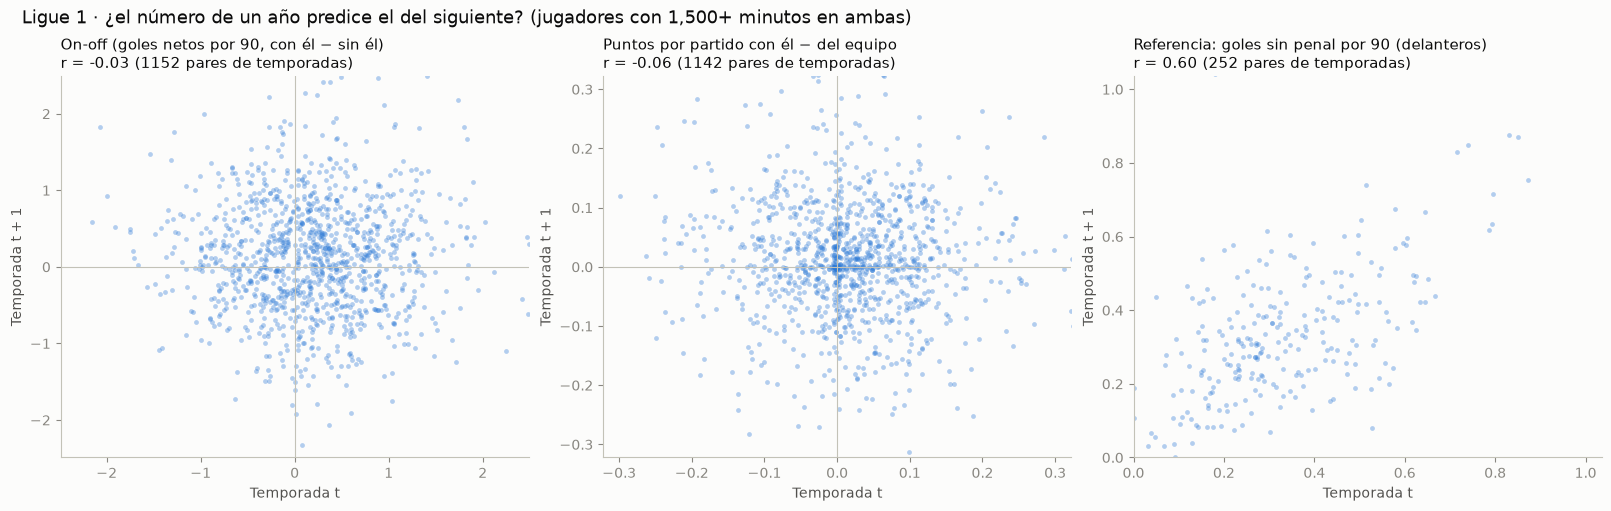

,r,pares
"On-off (goles netos por 90, con él − sin él)",-0.03,1152.0
Puntos por partido con él − del equipo,-0.06,1142.0
Referencia: goles sin penal por 90 (delanteros),0.60,252.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **−0.03** (1,152 pares) |
| Puntos por partido con él − del equipo | **−0.06** (1,142 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.60** (252 pares) |

Las dos medidas de impacto salen **negativas**: quien tuvo mejor on-off una temporada tendió, si acaso, a tenerlo
ligeramente peor a la siguiente. Es la demostración más clara de que con totales de temporada estas medidas son ruido.

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

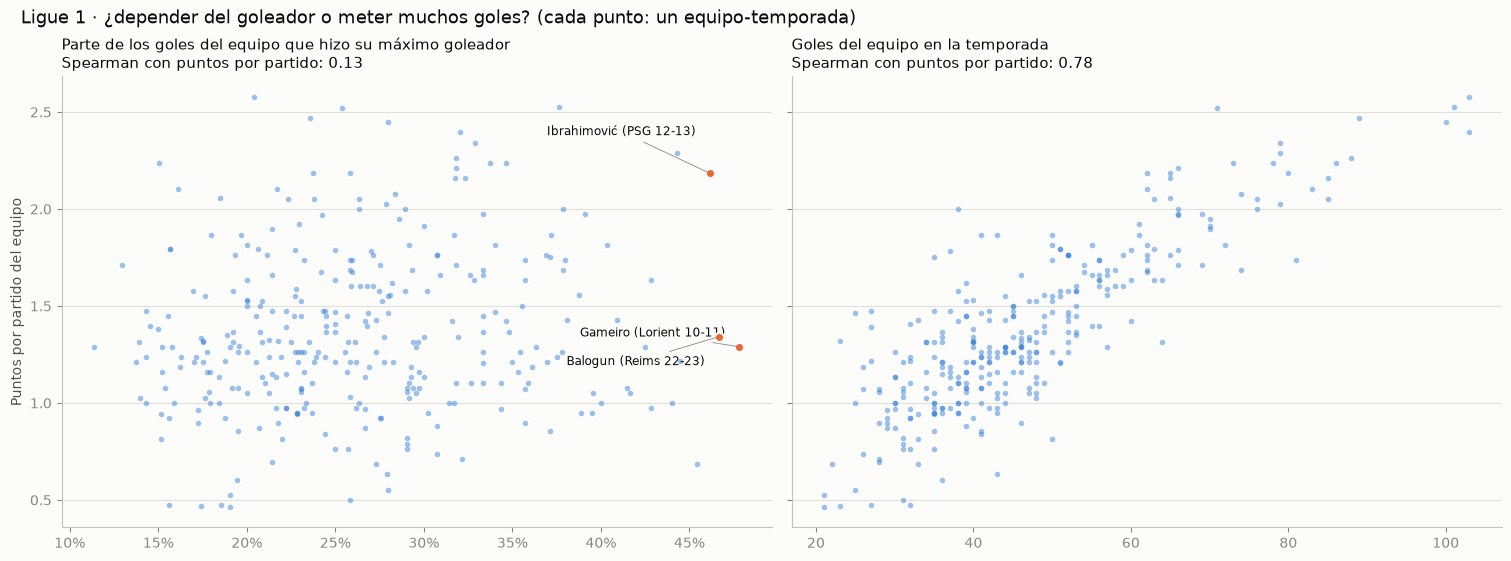

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
12,2010-2011,Lorient,Kévin Gameiro,22.0,46.0,0.48,1.29
248,2022-2023,Reims,Folarin Balogun,21.0,45.0,0.47,1.34
57,2012-2013,PSG,Zlatan Ibrahimović,30.0,65.0,0.46,2.18
158,2017-2018,Metz,Nolan Roux,15.0,33.0,0.45,0.68
197,2019-2020,Metz,Habib Diallo,12.0,27.0,0.44,1.21
136,2016-2017,PSG,Edinson Cavani,35.0,79.0,0.44,2.29
148,2017-2018,Caen,Ivan Santini,11.0,25.0,0.44,1.00
127,2016-2017,Caen,Ivan Santini,15.0,35.0,0.43,0.97


Mediana de la dependencia por temporada: {'2010-2011': 0.26, '2011-2012': 0.23, '2012-2013': 0.28, '2013-2014': 0.26, '2014-2015': 0.26, '2015-2016': 0.23, '2016-2017': 0.28, '2017-2018': 0.27, '2018-2019': 0.26, '2019-2020': 0.27, '2020-2021': 0.26, '2021-2022': 0.23, '2022-2023': 0.27, '2023-2024': 0.25, '2024-2025': 0.25, '2025-2026': 0.21}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- Dependencia del goleador vs. puntos: 0.13; goles del equipo: 0.78 (la más baja junto con la Liga MX, señal de una
  liga con más disparidad entre PSG y el resto).
- Los más dependientes: Kévin Gameiro (48% del Lorient 2010-11), Folarin Balogun (47% del Reims 2022-23) y, con
  resultados muy distintos, **Zlatan Ibrahimović** (46% del PSG 2012-13, 2.18 puntos por partido) y **Edinson
  Cavani** (35 goles, 44% del PSG 2016-17, 2.29).
- La dependencia mediana se mantiene entre 21% y 28%.

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
41333,Rennes,Esteban Lepaul,FW,21.0,5.0,161.0,1204.0,0.13,100.00
41525,Marseille,Mason Greenwood,MF,16.0,7.0,154.0,1231.0,0.13,100.00
41478,Auxerre,Lassine Sinayoko,FW,12.0,4.0,114.0,968.0,0.12,97.37
41361,Metz,Gauthier Hein,MF,8.0,7.0,110.0,1045.0,0.11,95.93
41417,Le Havre,Issa Soumaré,FW,8.0,5.0,107.0,1029.0,0.10,82.89
41500,Brest,Ludovic Ajorque,FW,8.0,9.0,111.0,1086.0,0.10,89.47
41290,Lyon,Corentin Tolisso,MF,11.0,4.0,117.0,1157.0,0.10,97.56
41345,Lens,Florian Thauvin,MF,11.0,6.0,127.0,1271.0,0.10,99.19
41603,Lorient,Pablo Pagis,MF,10.0,5.0,114.0,1146.0,0.10,96.75
41728,Toulouse,Yann Gboho,MF,8.0,3.0,106.0,1091.0,0.10,94.31


En 2025-26 el mejor jugador fantasy de cada equipo aporta hasta el 13% de los puntos de su equipo: **Esteban Lepaul**
(Rennes, 161 puntos) y **Mason Greenwood** (Marsella, 154), ambos en el percentil 100 de su posición.

## 5. Conclusiones y cómo ampliar a otra liga

**Ligue 1, 2010-11 a 2025-26:**

1. **Plantillas**: la mayor subida de extranjeros del panel (49% → 72.6% de los minutos) y muchos minutos para
   juveniles. Rotar vs. puntos: −0.35, con el PSG 2020-21 como excepción (rotó mucho y ganó).
2. **Porteros**: Sirigu domina las tres métricas. La liga pasó de ser la menos goleada (1.15 goles recibidos por
   partido en 2010-11) a estar en sus valores más altos (1.39-1.48).
3. **Impacto en cancha**: on-off −0.03 y puntos con él −0.06, las únicas correlaciones negativas del panel: ruido
   puro.
4. **Dependencia**: 0.13 con los puntos y 0.78 con los goles del equipo. Ibrahimović y Cavani son los casos de
   dependencia alta con mejores resultados.